In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [2]:
roma = pd.read_excel(r"C:\Users\Roman\Desktop\Arc_raiders\roma_kill.xlsx")
lena = pd.read_excel(r"C:\Users\Roman\Desktop\Arc_raiders\lena_kill.xlsx")
sc = pd.read_excel(r"C:\Users\Roman\Desktop\Arc_raiders\sc_kill.xlsx")
arc = pd.read_excel(r"C:\Users\Roman\Desktop\Arc_raiders\arc.xlsx")

# 1. Статистика трех игроков Arc raiders

In [3]:
roma['difference'] = roma['damage'] - roma['damage_received']
roma['efficiency'] = np.round(roma['damage'] / roma['damage_received'], 4)
roma['period_efficiency'] = (roma['damage'].diff() / roma['damage_received'].diff()).round(4)
roma['kill_per_period'] = (roma['kill'].diff().astype('Int64'))
roma['date'] = pd.to_datetime(roma['date'], format='%d.%m.%Y')

lena['difference'] = lena['damage'] - lena['damage_received']
lena['efficiency'] = np.round(lena['damage'] / lena['damage_received'], 4)
lena['period_efficiency'] = (lena['damage'].diff() / lena['damage_received'].diff()).round(4)
lena['kill_per_period'] = (lena['kill'].diff().astype('Int64'))
lena['date'] = pd.to_datetime(lena['date'], format='%d.%m.%Y')

sc['difference'] = sc['damage'] - sc['damage_received']
sc['efficiency'] = np.round(sc['damage'] / sc['damage_received'], 4)
sc['period_efficiency'] = (sc['damage'].diff() / sc['damage_received'].diff()).round(4)
sc['kill_per_period'] = (sc['kill'].diff().astype('Int64'))
sc['date'] = pd.to_datetime(sc['date'], format='%d.%m.%Y')

display(roma.tail(5))
display(lena.tail(5))
display(sc.tail(5))

,date,kill,nokaut,damage,damage_received,difference,efficiency,period_efficiency,kill_per_period
69,2026-03-04,909,666,137862,127761,10101,1.0791,1.2131,10
70,2026-03-09,941,692,142351,133127,9224,1.0693,0.8366,32
71,2026-03-12,958,708,144644,135528,9116,1.0673,0.9550,17
72,2026-03-13,985,730,148394,139344,9050,1.0649,0.9827,27
73,2026-03-19,1015,751,152469,143335,9134,1.0637,1.0210,30


,date,kill,nokaut,damage,damage_received,difference,efficiency,period_efficiency,kill_per_period
65,2026-03-05,469,318,66900,98091,-31191,0.6820,0.7718,5
66,2026-03-09,486,327,70045,102743,-32698,0.6817,0.6761,17
67,2026-03-12,497,332,71220,104412,-33192,0.6821,0.7040,11
68,2026-03-13,521,343,74172,107625,-33453,0.6892,0.9188,24
69,2026-03-19,538,352,76022,110285,-34263,0.6893,0.6955,17


,date,kill,nokaut,damage,damage_received,difference,efficiency,period_efficiency,kill_per_period
9,2026-02-01,296,191,42230,52777,-10547,0.8002,0.9992,27
10,2026-03-09,388,258,55055,64429,-9374,0.8545,1.1007,92
11,2026-03-12,401,269,56314,65381,-9067,0.8613,1.3225,13
12,2026-03-13,415,287,58643,67750,-9107,0.8656,0.9831,14
13,2026-03-19,437,304,61993,70575,-8582,0.8784,1.1858,22


In [4]:
def graphics1(data, colour_kill='red', colour_nokaut='blue'):
    plt.figure(figsize=(15,6))
    plt.plot(data.index, data['kill'], marker='o', linestyle='-', color=colour_kill, label = 'kill')
    plt.plot(data.index, data['nokaut'], marker='o', linestyle='-', color=colour_nokaut, label = 'nokaut')
    plt.title('Kill и Nokaut по датам')
    plt.xticks(data.index[::3], data['date'].dt.strftime('%d.%m.%Y')[::3], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.figure(figsize=(15,6))
    plt.plot(data.index, data['kill_per_period'], marker='o', linestyle='-', color=colour_kill)
    plt.title('Убийства за сессию')
    plt.xticks(data.index[::3], data['date'].dt.strftime('%d.%m.%Y')[::3], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)


def graphics2(data, colour='red', target_efficiency = 1):
    plt.figure(figsize=(15,6))
    plt.plot(data.tail(30).index, data.tail(30)['efficiency'], marker='o', color=colour)
    plt.title('Общая эффективность')
    plt.xticks(data.tail(30).index[::3], data.tail(30)['date'].dt.strftime('%d.%m.%Y')[::3], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)


    plt.figure(figsize=(15,6))
    plt.plot(data.index, data['period_efficiency'], marker='o', color=colour)
    plt.axhline(y=target_efficiency, linestyle='--', linewidth=2)
    plt.title('Эффективность за сессию')
    plt.xticks(data.index[::3], data['date'].dt.strftime('%d.%m.%Y')[::3], rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)

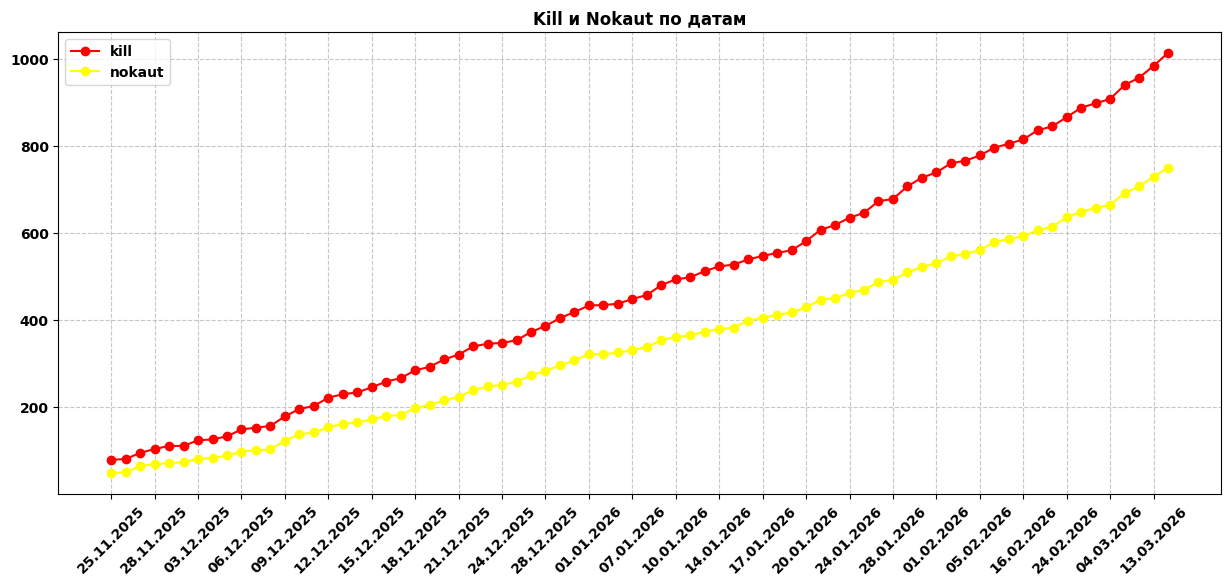

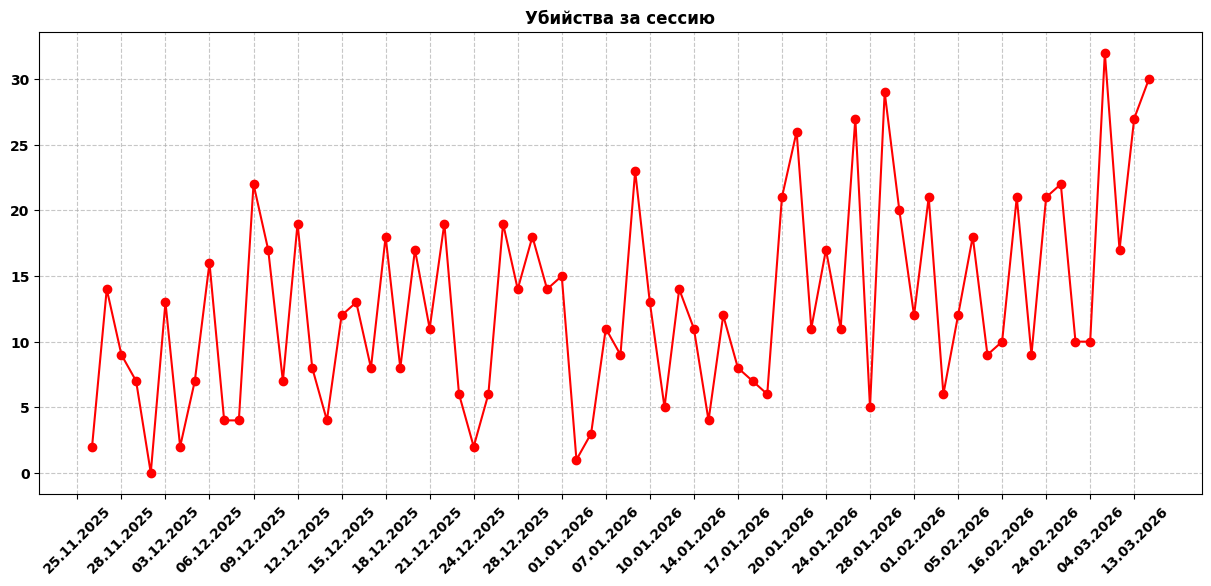

In [5]:
graphics1(roma, colour_kill='red', colour_nokaut = 'yellow')

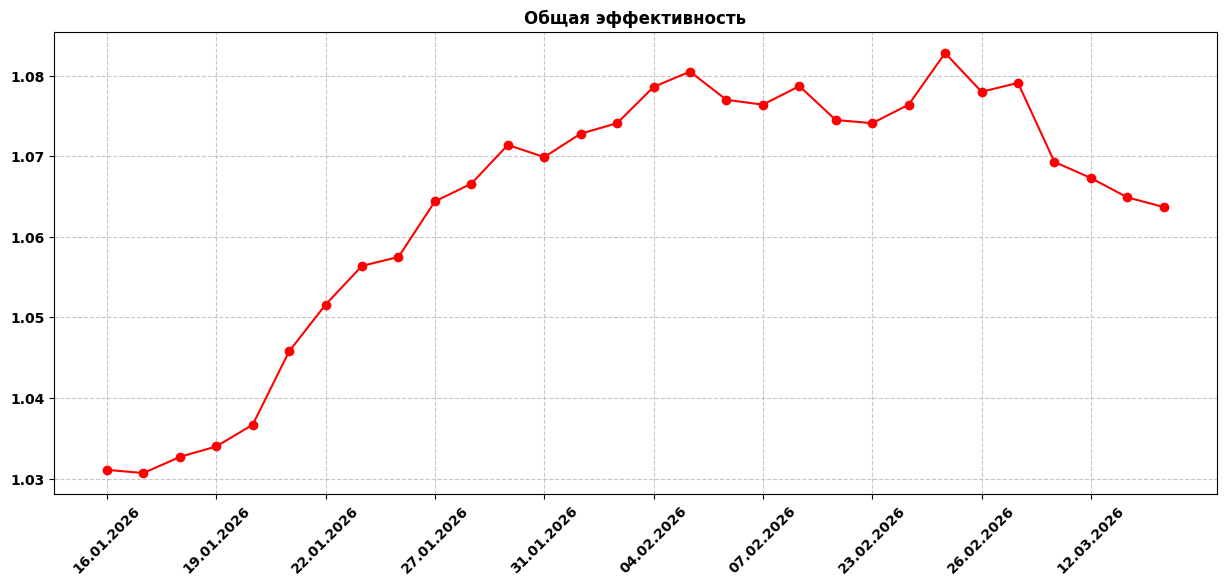

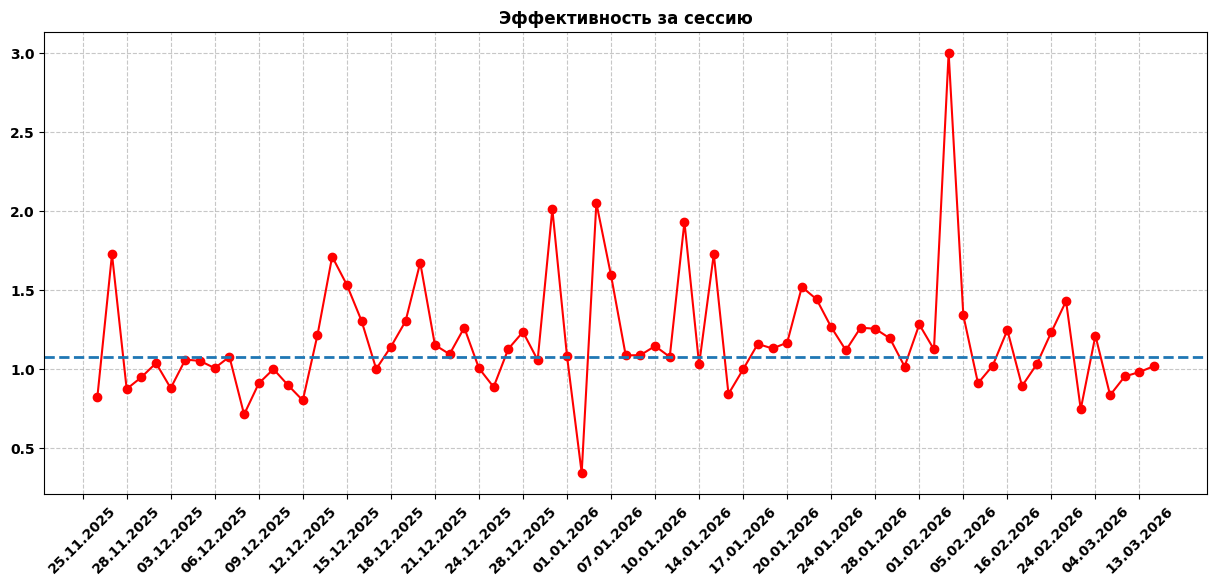

In [6]:
graphics2(roma, colour='red', target_efficiency = 1.08)

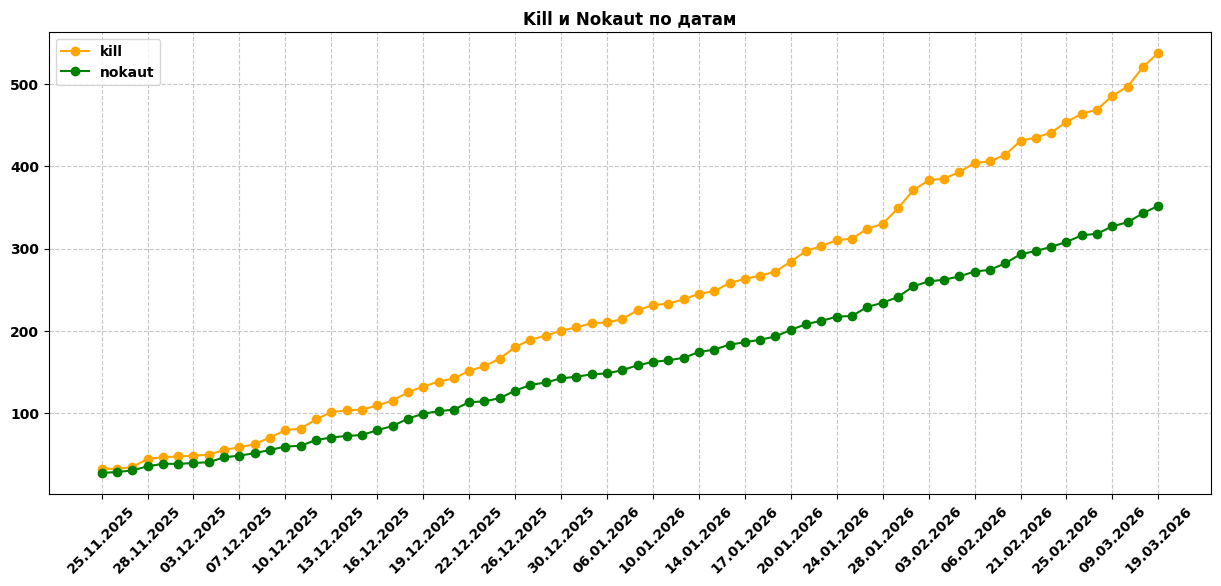

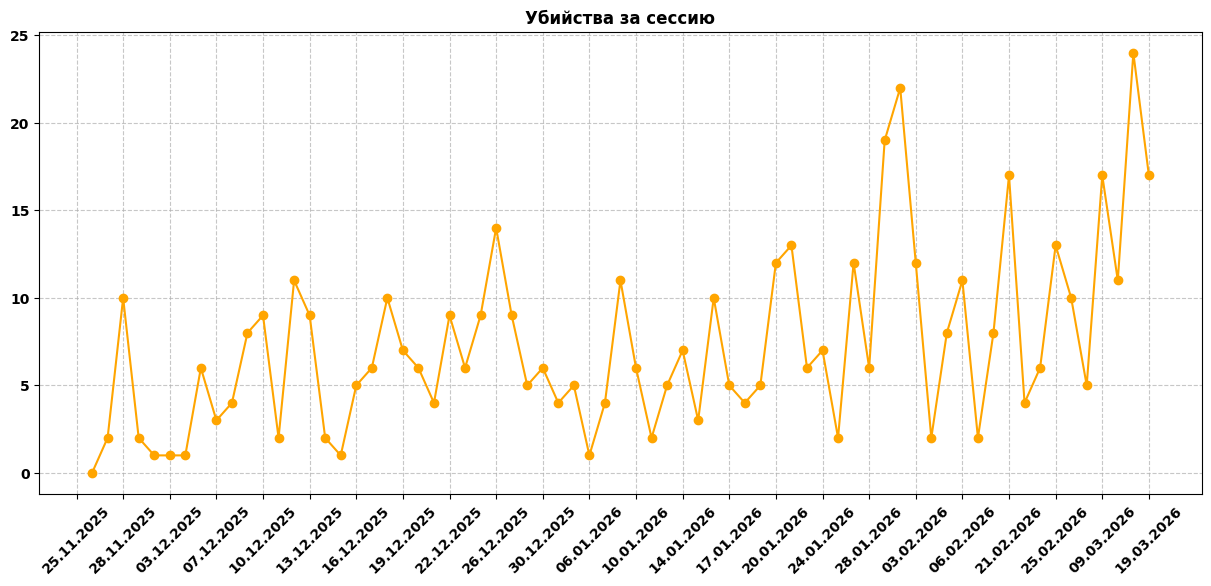

In [7]:
graphics1(lena, colour_kill='orange', colour_nokaut = 'green')

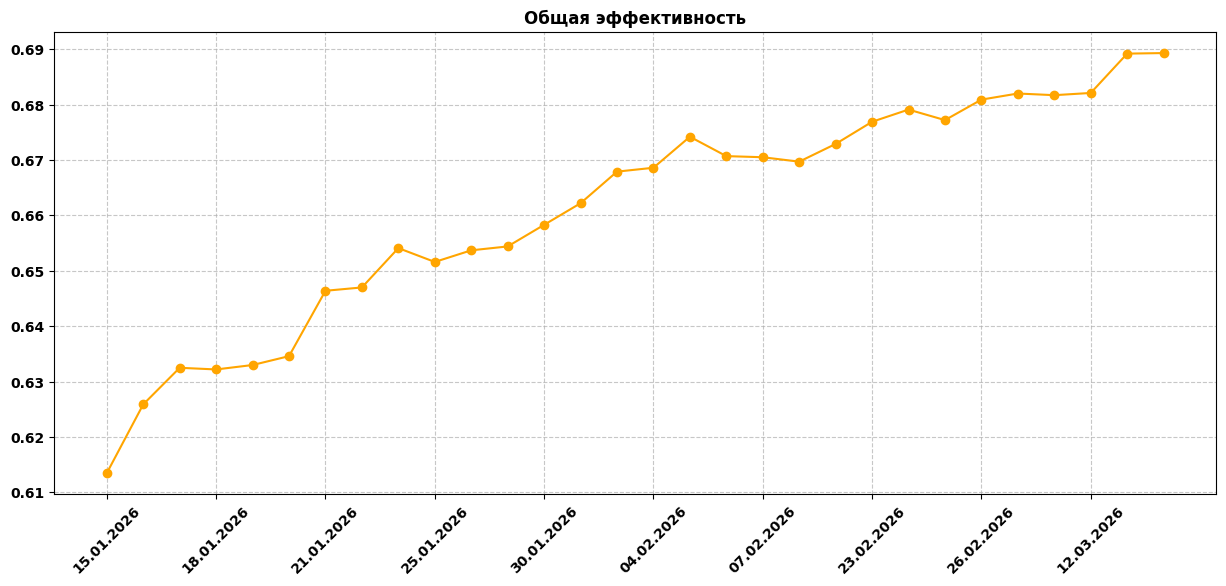

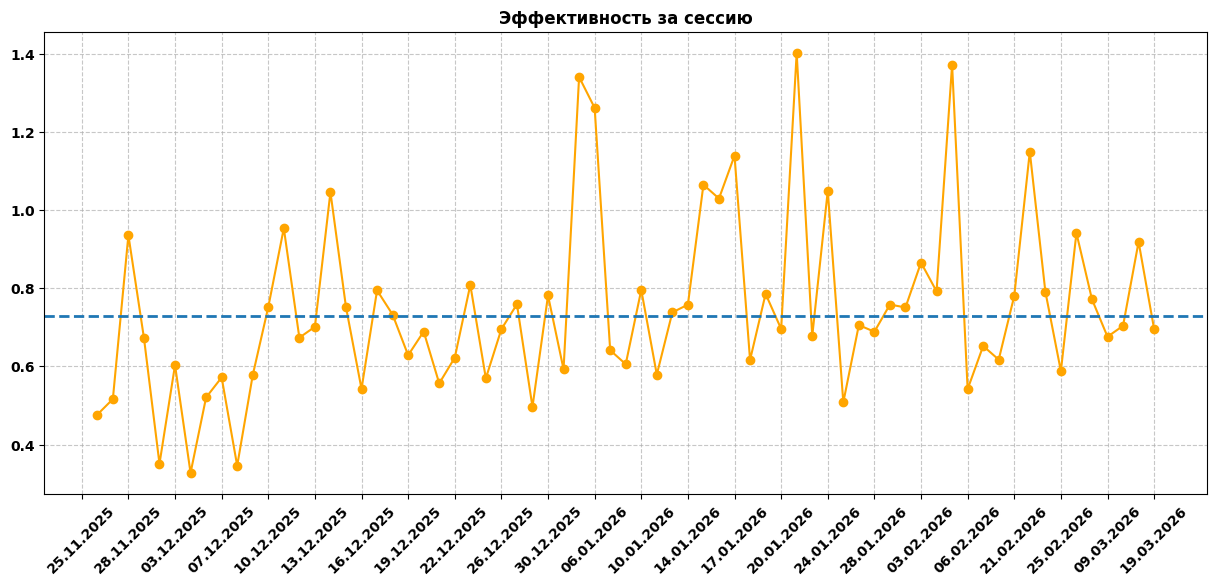

In [8]:
graphics2(lena, colour='orange', target_efficiency = 0.73)

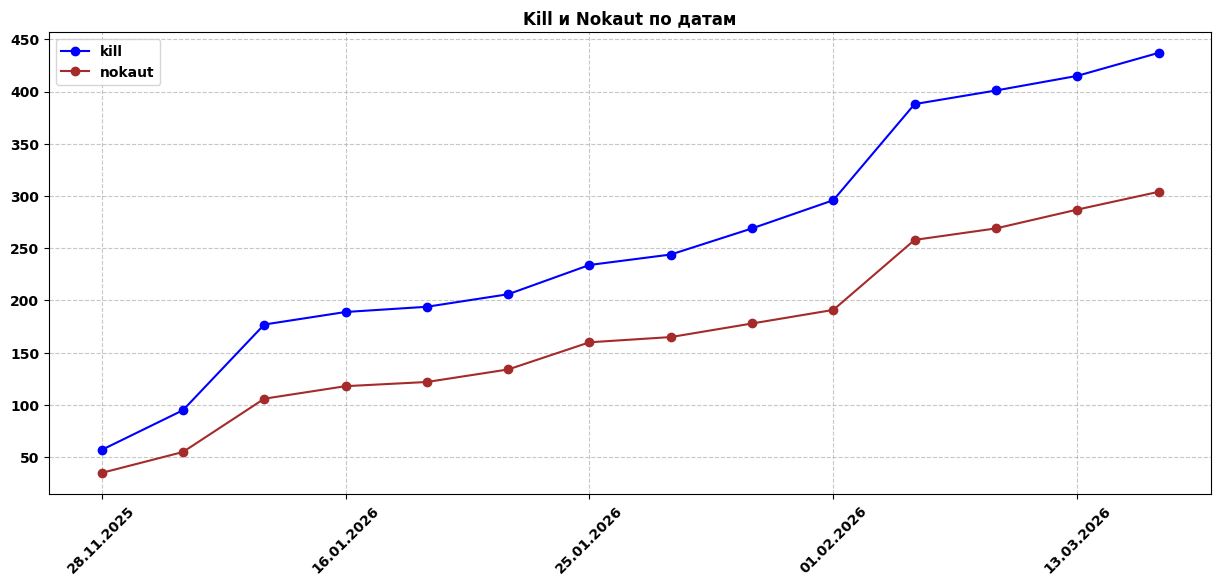

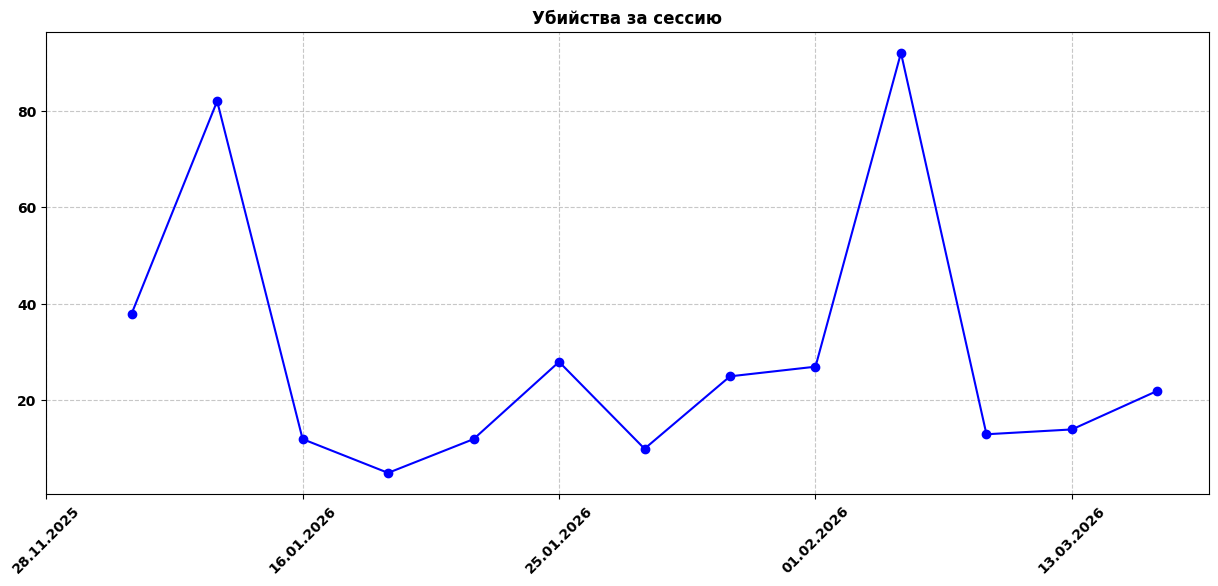

In [9]:
graphics1(sc, colour_kill='blue', colour_nokaut = 'brown')

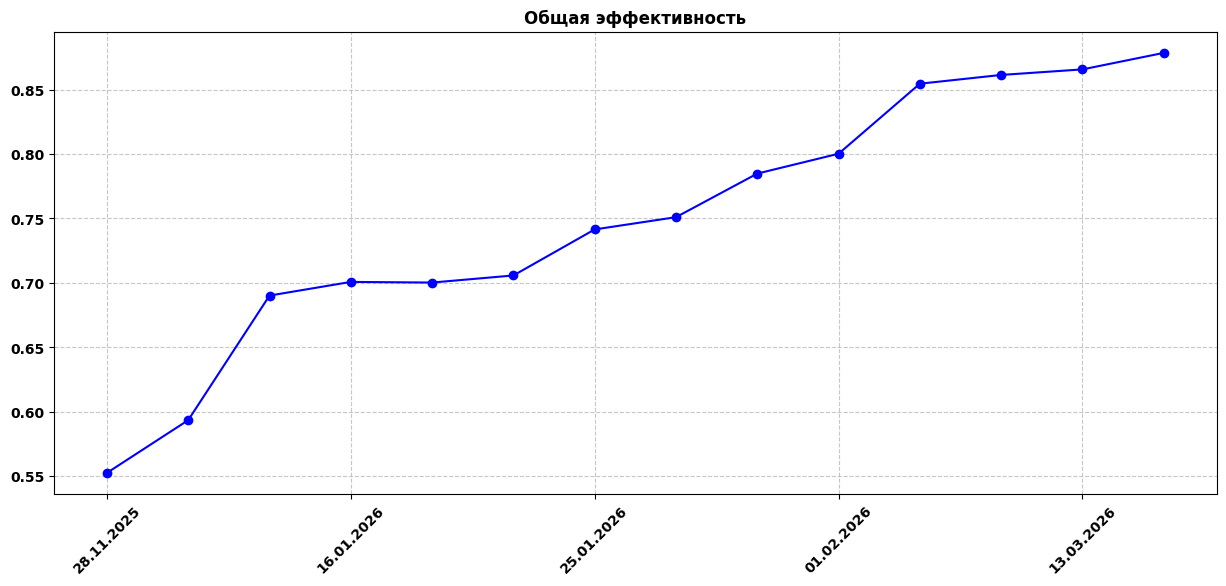

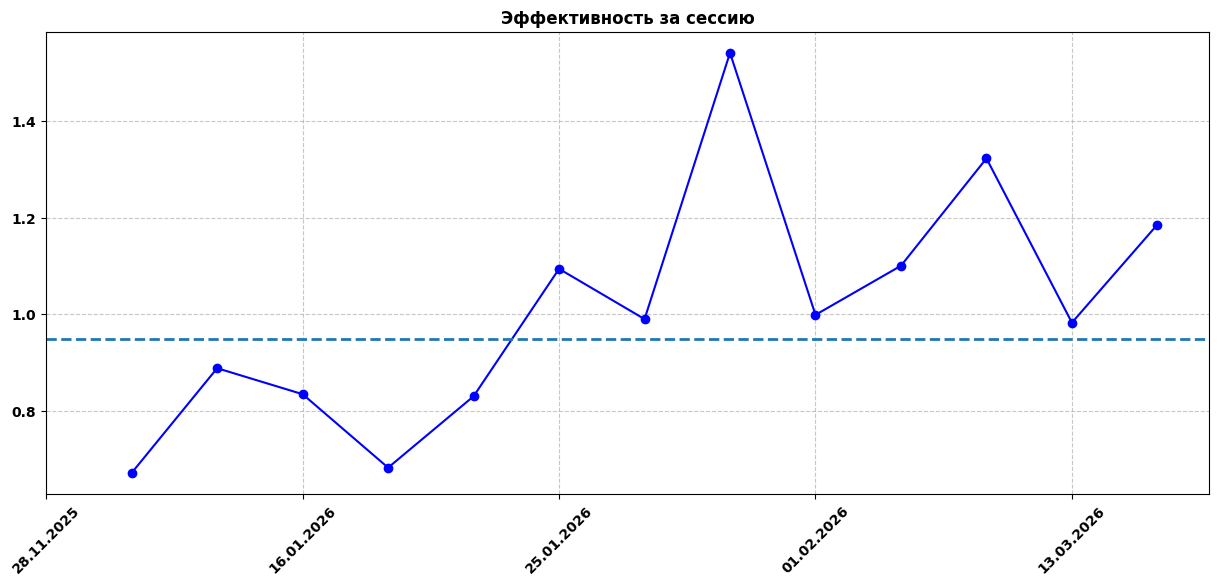

In [10]:
graphics2(sc, colour='blue', target_efficiency = 0.95)

# 2. Статистика взаимодействий с Арками

In [11]:
arc['damage_ratio_25_12'] = round(arc['arc_damage_received_25_12'] / arc['arc_damage_25_12'] * 100, 2)
arc['damage_ratio_26_03'] = round(arc['arc_damage_received_26_03'] / arc['arc_damage_26_03'] * 100, 2)
arc['ratio_diff'] = arc['damage_ratio_26_03'] - arc['damage_ratio_25_12']
arc['ratio_change_pct'] = round((arc['damage_ratio_26_03'] / arc['damage_ratio_25_12'] - 1) * 100, 2)

arc['arc_damage_share_25_12'] = round(arc['arc_damage_received_25_12'] / arc['arc_damage_received_25_12'].sum() * 100, 2)
arc['arc_damage_share_26_03'] = round(arc['arc_damage_received_26_03'] / arc['arc_damage_received_26_03'].sum() * 100, 2)
arc['share_diff'] = arc['arc_damage_share_26_03'] - arc['arc_damage_share_25_12']

display(arc)


ratio_25 = round(arc['arc_damage_received_25_12'].sum() / arc['arc_damage_25_12'].sum() * 100,2)
ratio_26 = round(arc['arc_damage_received_26_03'].sum() / arc['arc_damage_26_03'].sum() * 100,2)
change_pct = (ratio_26 / ratio_25 - 1) * 100

print(f"нанесено урона дронам, декабрь 2025:", arc['arc_damage_25_12'].sum())
print(f"получено урона от дронов, декабрь 2025:", arc['arc_damage_received_25_12'].sum())
print(f"соотношение полученного урона, декабрь 2025: {ratio_25} %", '\n')

print(f"нанесено урона дронам, март 2026:", arc['arc_damage_26_03'].sum())
print(f"получено урона от дронов, март 2026:", arc['arc_damage_received_26_03'].sum())
print(f"соотношение полученного урона, март 2026: {round(arc['arc_damage_received_26_03'].sum() / arc['arc_damage_26_03'].sum() *100, 3)} %", '\n')

print(f"изменение соотношения полученного урона: {change_pct:.3f}%")

,drone,arc_kills_26_03,arc_damage_25_12,arc_damage_26_03,arc_damage_received_25_12,arc_damage_received_26_03,damage_ratio_25_12,damage_ratio_26_03,ratio_diff,ratio_change_pct,arc_damage_share_25_12,arc_damage_share_26_03,share_diff
0,оса,1233,55064.0,162166,3819.0,6985,6.94,4.31,-2.63,-37.90,22.49,16.16,-6.33
1,шершень,467,42640.0,121391,3217.0,5948,7.54,4.90,-2.64,-35.01,18.94,13.76,-5.18
2,часовой,23,2074.0,6510,340.0,677,16.39,10.40,-5.99,-36.55,2.00,1.57,-0.43
3,бастион,12,4978.0,25431,344.0,1657,6.91,6.52,-0.39,-5.64,2.03,3.83,1.80
4,клещ,516,987.0,5171,429.0,1129,43.47,21.83,-21.64,-49.78,2.53,2.61,0.08
5,бомбардир,5,3505.0,27903,570.0,1925,16.26,6.90,-9.36,-57.56,3.36,4.45,1.09
6,взрывобот,824,2699.0,16582,1876.0,5206,69.51,31.40,-38.11,-54.83,11.05,12.04,0.99
7,королева,3,1629.0,45710,328.0,1157,20.14,2.53,-17.61,-87.44,1.93,2.68,0.75
8,матриарх,1,1068.0,36904,21.0,494,1.97,1.34,-0.63,-31.98,0.12,1.14,1.02
9,огнешар,665,2661.0,13219,296.0,889,11.12,6.73,-4.39,-39.48,1.74,2.06,0.32


нанесено урона дронам, декабрь 2025: 154047.0
получено урона от дронов, декабрь 2025: 16982.0
соотношение полученного урона, декабрь 2025: 11.02 % 

нанесено урона дронам, март 2026: 626639
получено урона от дронов, март 2026: 43234
соотношение полученного урона, март 2026: 6.899 % 

изменение соотношения полученного урона: -37.387%


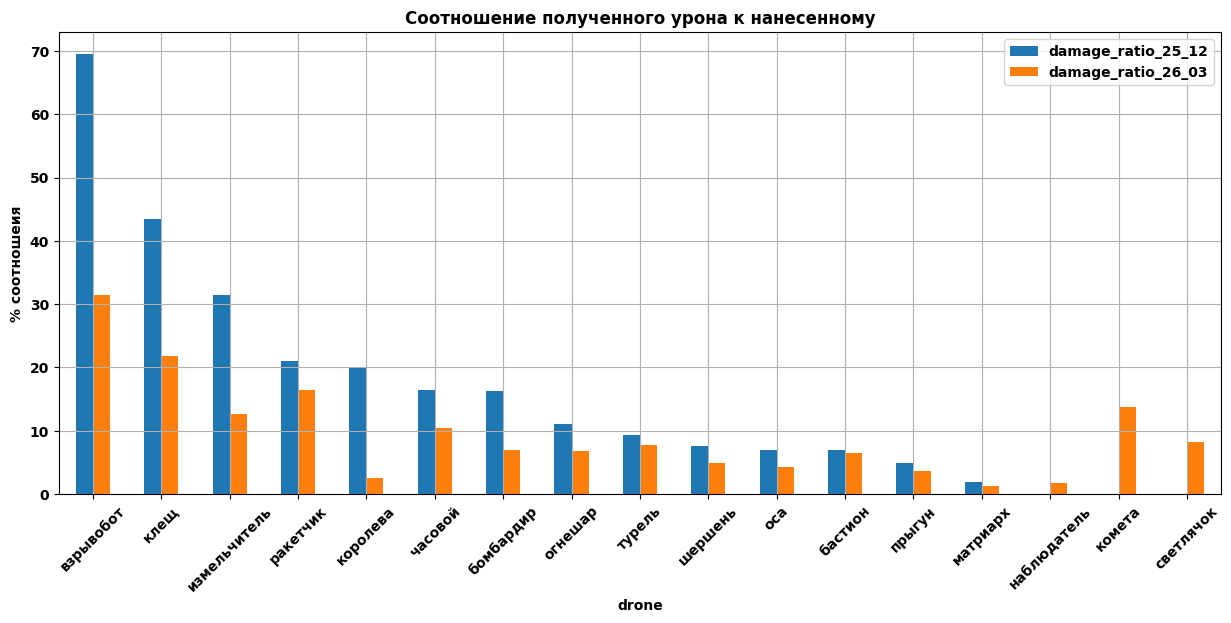

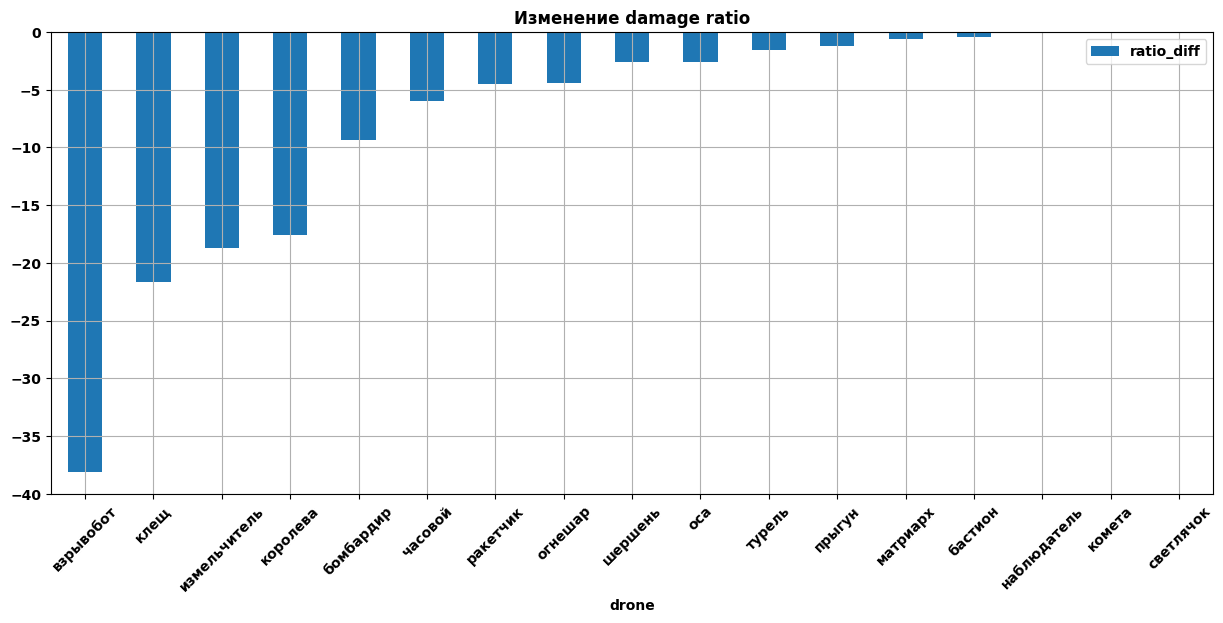

In [12]:
arc_sorted_ratio = arc.sort_values(by = 'damage_ratio_25_12', ascending=False)

arc_sorted_ratio.plot(x='drone', y=['damage_ratio_25_12', 'damage_ratio_26_03'], kind='bar', figsize=(15,6))
plt.ylabel('% соотношеия')
plt.title('Соотношение полученного урона к нанесенному')
plt.xticks(rotation=45)
plt.grid(True)

arc_sorted_ratio_diff = arc.sort_values(by = 'ratio_diff')
arc_sorted_ratio_diff.plot(x='drone', y='ratio_diff', kind='bar', figsize=(15,6))
plt.title('Изменение damage ratio')
plt.xticks(rotation=45)
plt.grid(True);

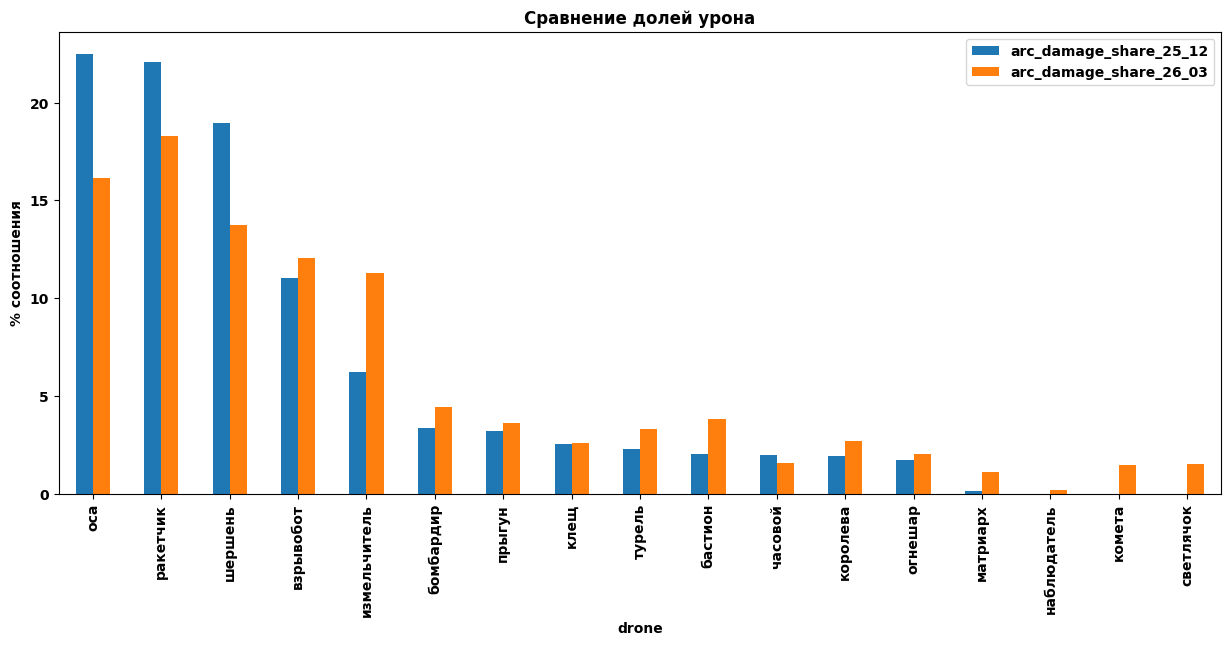

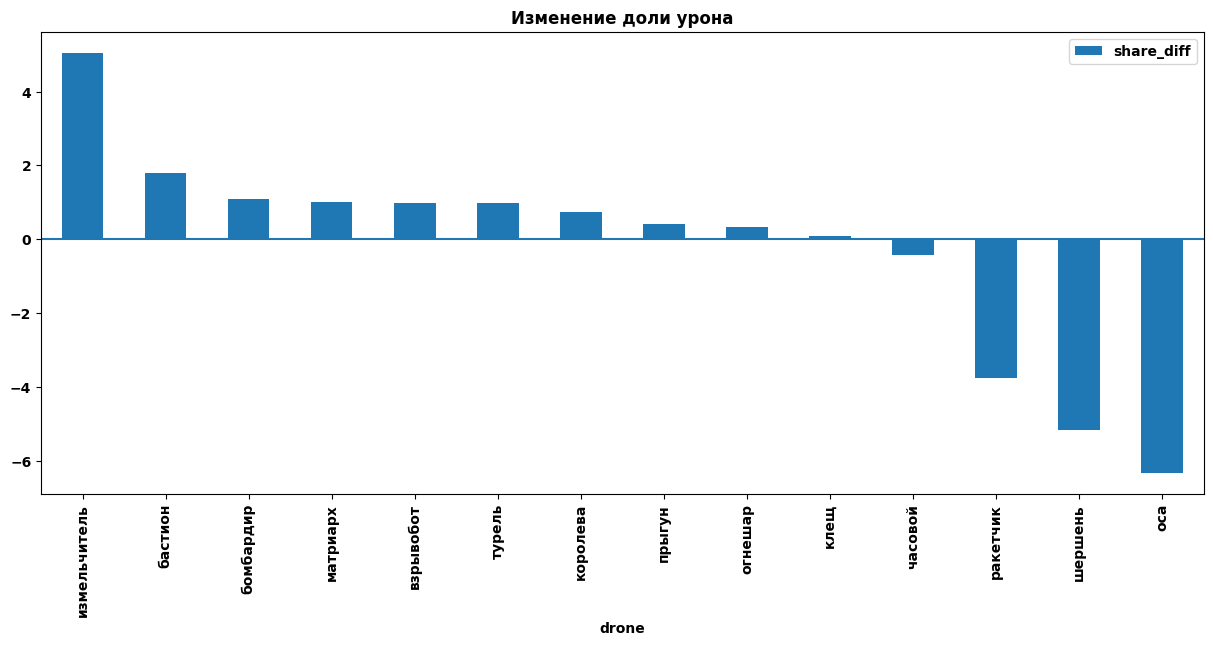

In [13]:
arc_sorted_share_25_12 = arc.sort_values(by = 'arc_damage_share_25_12', ascending=False)

arc_sorted_share_25_12.plot(x='drone', y=['arc_damage_share_25_12', 'arc_damage_share_26_03'], kind='bar', figsize=(15,6))
plt.ylabel('% соотношения')
plt.title('Сравнение долей урона');


arc_share_diff = arc.sort_values('share_diff', ascending=False).dropna(subset = ['share_diff'])
arc_share_diff.plot(x='drone', y='share_diff', kind='bar', figsize=(15,6))
plt.axhline(0)
plt.title('Изменение доли урона');

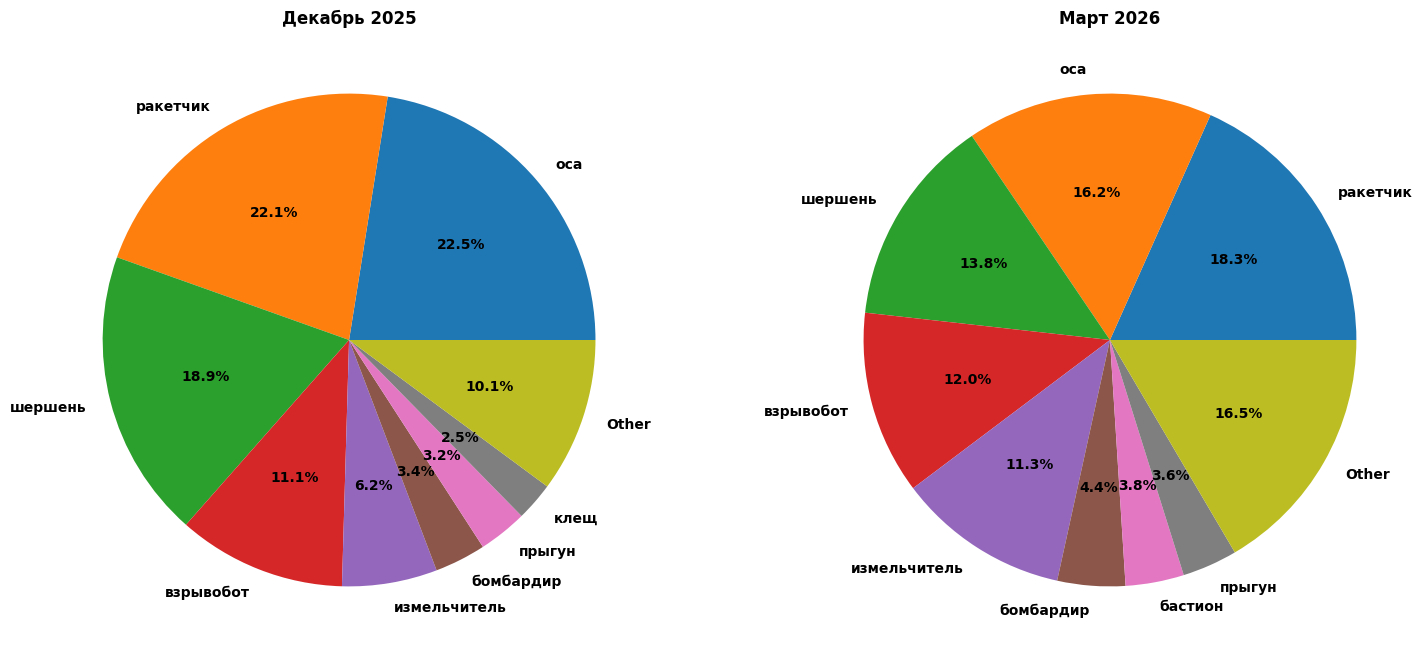

In [14]:
arc_sorted_share_25_12 = arc.sort_values(by = 'arc_damage_share_25_12', ascending=False)
arc_sorted_share_26_03 = arc.sort_values(by = 'arc_damage_share_26_03', ascending=False)

top_8 = arc_sorted_share_25_12.head(8)
other_sum = arc_sorted_share_25_12.iloc[8:]['arc_damage_share_25_12'].sum()
labels = list(top_8['drone']) + ['Other']
values = list(top_8['arc_damage_share_25_12']) + [other_sum]

top_10_26 = arc_sorted_share_26_03.head(8)
other_sum_26 = arc_sorted_share_26_03.iloc[8:]['arc_damage_share_26_03'].sum()
labels_26 = list(top_10_26['drone']) + ['Other']
values_26 = list(top_10_26['arc_damage_share_26_03']) + [other_sum_26]



fig, axes = plt.subplots(1, 2, figsize=(18,8))

axes[0].pie(values, labels=labels, autopct='%1.1f%%')
axes[0].set_title('Декабрь 2025')

axes[1].pie(values_26, labels=labels_26, autopct='%1.1f%%')
axes[1].set_title('Март 2026');